# Mini Projet Prompt Engineering – AI Business Assistant

**Contexte** : une entreprise souhaite mettre en place « AI Business Assistant », un assistant IA polyvalent capable d'aider ses collaborateurs à exploiter des documents, analyser des données, faire du machine learning et produire des résultats structurés.

**LLM utilisé** : ChatGPT (interface web).

**Démarche** : pour chaque tâche demandée :
1. le **prompt** utilisé ;
2. la **capture** de la réponse de ChatGPT ;
3. les **observations**.

**Sommaire**
- Partie 1 – Anatomie d'un prompt
- Partie 2 – Comparer les techniques de prompting
- Partie 3 – Prompt Engineering et raisonnement
- Partie 4 – Sorties structurées
- Partie 5 – Prompts pour les applications métier
- Partie 6 – Prompt Engineering pour le Machine Learning
- Partie 7 – Prompt Engineering et RAG
- Partie 8 – Évaluation et optimisation des prompts
- Partie 9 – Bonus

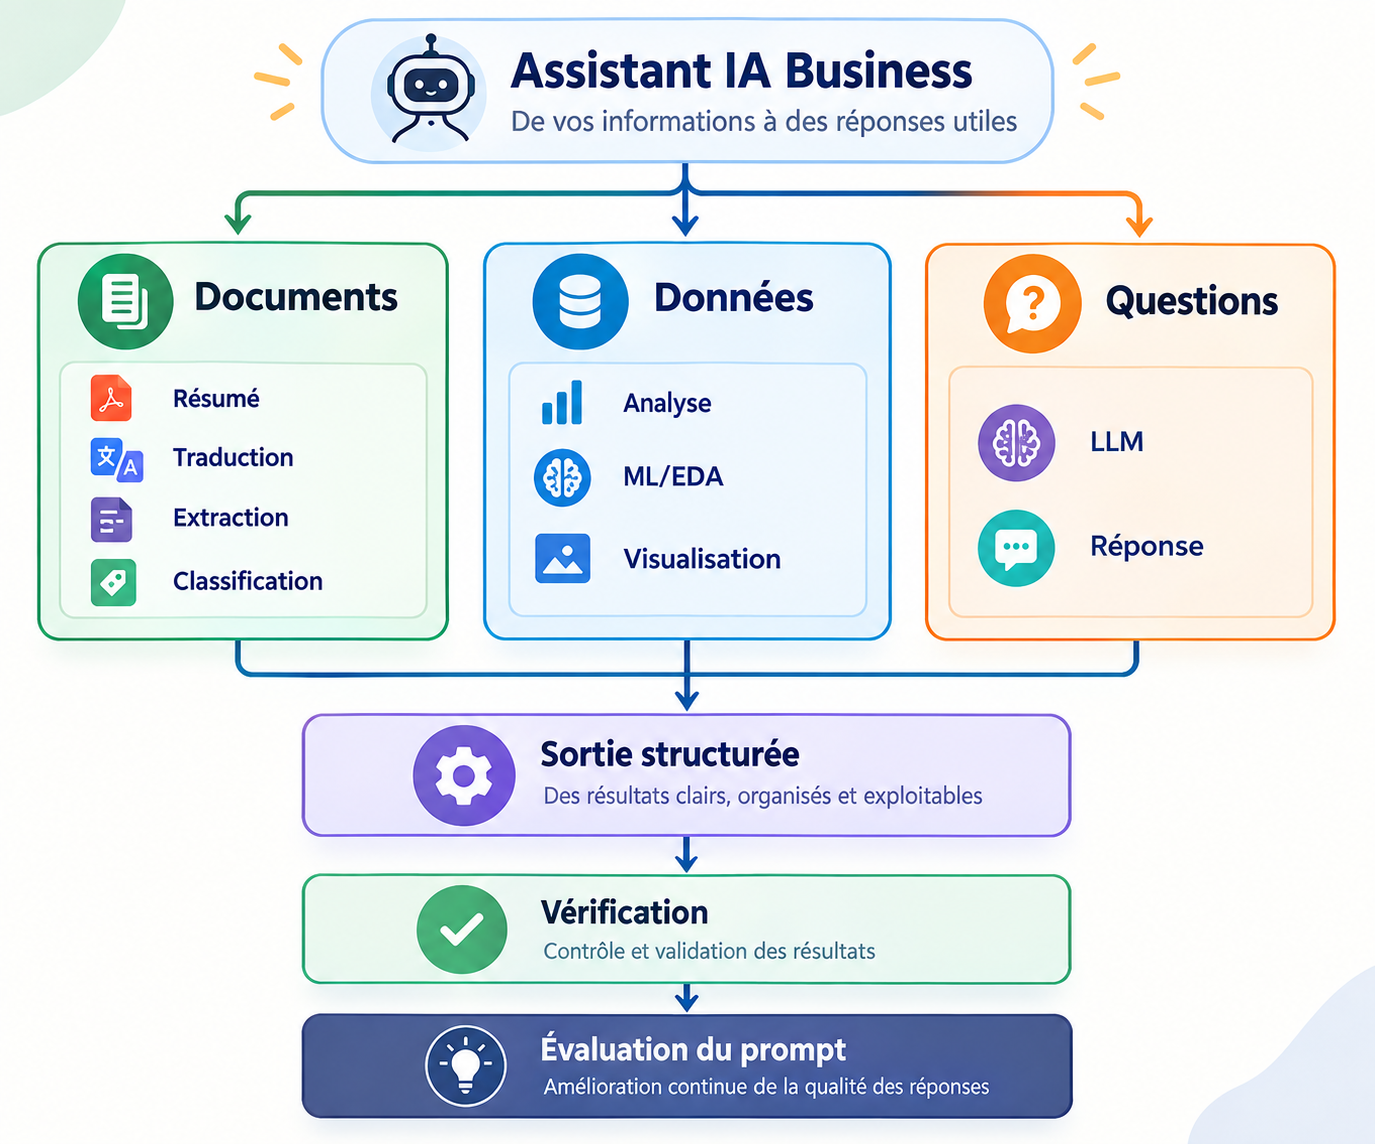

---
## Partie 1 – Anatomie d'un prompt

> **Consigne** : construire un prompt, à partir de ses différentes composantes, pour résoudre un problème comme « *Je souhaite analyser les retours de clients d'une entreprise.* »

Nous constatons que cette demande est trop vague : le modèle ne sait ni quels retours analyser, ni quel type d'analyse produire, ni pour qui, ni sous quelle forme

### Les composantes d'un prompt

| Composante | Rôle | Question à laquelle elle répond |
|---|---|---|
| **Rôle** | Fixe l'expertise et le point de vue du modèle | Qui répond ? |
| **Contexte** | Situe la demande : entreprise, enjeu, destinataire | Pourquoi et pour qui ? |
| **Tâche** | Décrit précisément le résultat attendu | Que faut-il faire ? |
| **Instructions** | Découpe le travail en étapes | Comment procéder ? |
| **Contraintes** | Pose les limites : sources, longueur, interdits | Que ne faut-il pas faire ? |
| **Format de sortie** | Impose la structure de la réponse | Sous quelle forme ? |
| **Ton** | Adapte le registre au lecteur | Comment le dire ? |
| **Données** | Fournit le contenu à traiter, entre délimiteurs | Sur quoi travailler ? |
| **Exemples** *(optionnel)* | Montre une réponse attendue | À quoi ressemble une bonne réponse ? |

## Prompt

Les avis sont ceux de **ShopNet**, une enseigne de e-commerce fictive.

```text
# RÔLE
Tu es analyste de l'expérience client, spécialisé dans le e-commerce.

# CONTEXTE
ShopNet est une enseigne de vente en ligne (site web + application mobile)
qui livre ses clients à domicile. La direction de l'expérience client veut
savoir quels problèmes corriger en priorité. Le rapport sera lu par des
managers non techniques.

# TÂCHE
Analyse les avis clients fournis entre les balises <avis> et </avis>.

# INSTRUCTIONS
1. Attribue à chaque avis un sentiment : positif, négatif ou mitigé
   (un avis mitigé contient un point positif et un point négatif).
2. Regroupe les avis par thème : livraison, application mobile, paiement,
   service client, prix, produit, emballage.
3. Classe les problèmes par priorité selon le nombre d'avis concernés,
   la gravité et le risque de perdre le client.
4. Signale les avis qui demandent une action immédiate.
5. Propose une recommandation concrète pour chaque problème prioritaire.

# CONTRAINTES
- Utilise uniquement les avis fournis et cite leurs identifiants (ex. A03)
  pour justifier chaque constat.
- N'invente aucune information. Si une cause n'est pas établie,
  présente-la comme une hypothèse.
- 400 mots maximum, tableaux non compris.

# FORMAT DE SORTIE
Réponds en Markdown avec ces sections :
1. Synthèse (3 phrases maximum)
2. Répartition des sentiments (tableau : Sentiment | Nombre | Identifiants)
3. Problèmes prioritaires (tableau : Rang | Problème | Avis concernés |
   Gravité faible/moyenne/élevée | Justification)
4. Avis à traiter immédiatement
5. Recommandations
6. Limites de l'analyse

# TON
Professionnel, factuel et direct.

# DONNÉES
<avis>
A01 : Application très pratique, je commande en 2 minutes. Livraison reçue le lendemain, parfait.
A02 : Ma commande devait arriver mardi, je l'ai reçue le samedi suivant. Personne ne m'a prévenu du retard.
A03 : L'application plante à chaque fois que je veux payer par carte. J'ai dû passer par le site.
A04 : Le conseiller a été très aimable et a résolu mon problème de remboursement en un appel.
A05 : Le service est rapide mais l'application plante régulièrement.
A06 : J'ai été débité deux fois pour la même commande (45 000 FCFA). J'attends un remboursement depuis 10 jours, sans réponse.
A07 : Produits conformes à la description, bon rapport qualité-prix.
A08 : Troisième retard de livraison ce mois-ci. Si ça continue, je vais chez un concurrent.
A09 : Colis arrivé avec l'emballage déchiré, mais le produit était intact.
A10 : Impossible de joindre le service client : 40 minutes d'attente au téléphone et aucune réponse au chat.
A11 : Depuis la dernière mise à jour, l'appli se ferme toute seule sur mon téléphone Android.
A12 : Les frais de livraison ont augmenté sans que ce soit annoncé clairement.
</avis>
```

# Partie 2 - Comparaisons des techniques de prompting

### 1. Zero-shot
*Aucun exemple : le modèle ne reçoit que la consigne.*

```text
Classe le commentaire suivant.

Commentaire : « Le service est rapide mais l'application plante régulièrement. »

Classes possibles : positif, négatif, neutre.
```

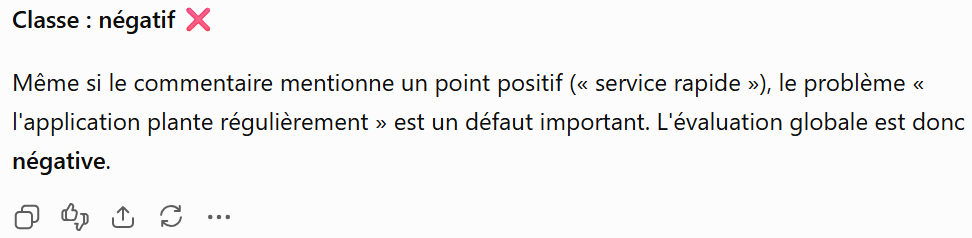

### 2. One-shot
*Un seul exemple de commentaire déjà classé.*

```text
Classe le commentaire en positif, négatif ou neutre.

Exemple :
- « Livraison reçue le lendemain, parfait. » ====> positif

Commentaire à classer : « Le service est rapide mais l'application plante régulièrement. »

Classe :
```

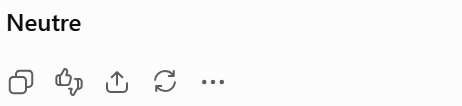

### 3. Few-shot
*Plusieurs exemples, dont un commentaire mixte qui montre comment trancher.*

```text
Classe le commentaire en positif, négatif ou neutre.

Exemples :
- « Produits conformes, bon rapport qualité-prix. » ===> positif
- « Impossible de joindre le service client, aucune réponse. » ===> négatif
- « Commande reçue ce matin. » ===> neutre
- « Prix intéressants mais le colis est arrivé cassé. » ===> négatif

Commentaire à classer : « Le service est rapide mais l'application plante régulièrement. »

Classe :
```

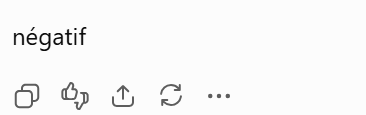